In [2]:
# 필수 라이브러리 Import
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

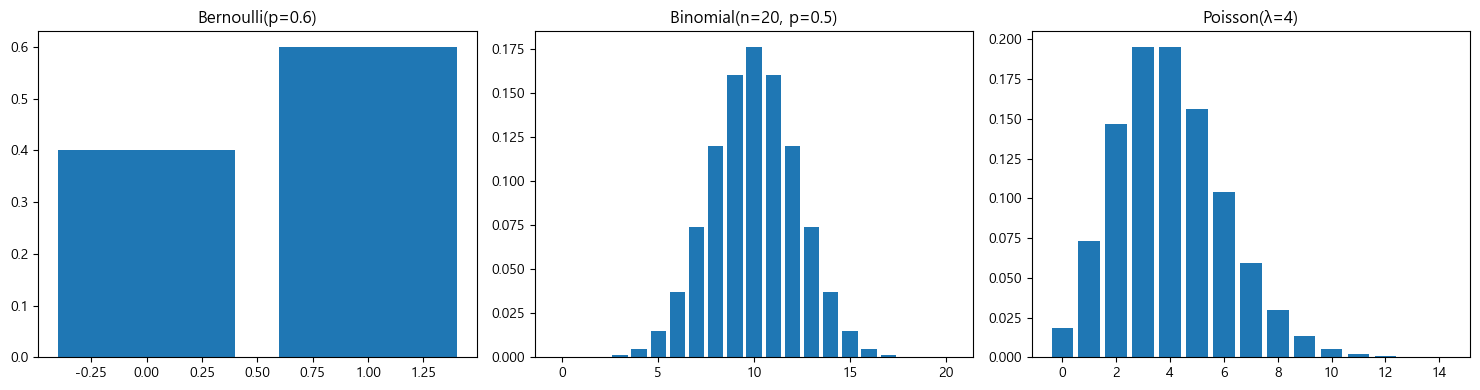

In [3]:
# ⚡ Quick Copy — 이산형 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 베르누이
from scipy.stats import bernoulli, binom, poisson
ax = axes[0]
x = [0, 1]
ax.bar(x, bernoulli.pmf(x, p=0.6))
ax.set_title('Bernoulli(p=0.6)')

# 이항
ax = axes[1]
x = np.arange(0, 21)
ax.bar(x, binom.pmf(x, n=20, p=0.5))
ax.set_title('Binomial(n=20, p=0.5)')

# 포아송
ax = axes[2]
x = np.arange(0, 15)
ax.bar(x, poisson.pmf(x, mu=4))
ax.set_title('Poisson(λ=4)')

plt.tight_layout()
plt.show()

회귀 계수: [[2.9902591]]
절편: [4.20634019]
평균 제곱 오차(MSE): 0.9177532469714291
결정 계수(R2): 0.6521157503858556


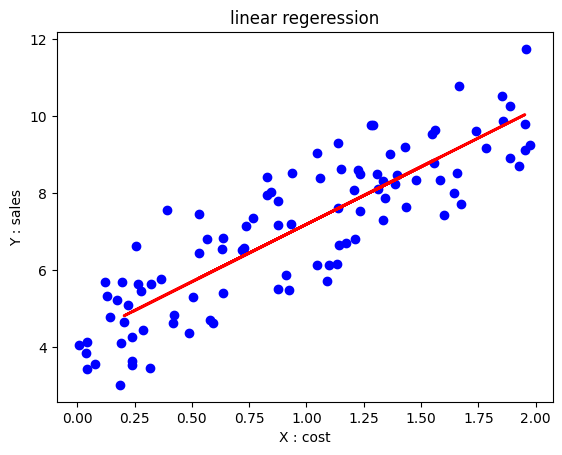

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 예시 데이터 생성
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 단순선형회귀 모델 생성 및 훈련
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 회귀 계수 및 절편 출력
print("회귀 계수:", model.coef_)
print("절편:", model.intercept_)

# 모델 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("평균 제곱 오차(MSE):", mse)
print("결정 계수(R2):", r2)

# 시각화
plt.scatter(X, y, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.title('linear regeression')
plt.xlabel('X : cost')
plt.ylabel('Y : sales')
plt.show()

In [2]:
# 예시 데이터 생성
data = {'TV': np.random.rand(100) * 100,
        'Radio': np.random.rand(100) * 50,
        'Newspaper': np.random.rand(100) * 30,
        'Sales': np.random.rand(100) * 100}
df = pd.DataFrame(data)

# 독립 변수(X)와 종속 변수(Y) 설정
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 다중선형회귀 모델 생성 및 훈련
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 회귀 계수 및 절편 출력
print("회귀 계수:", model.coef_)
print("절편:", model.intercept_)

# 모델 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("평균 제곱 오차(MSE):", mse)
print("결정 계수(R2):", r2)

회귀 계수: [-0.02208636 -0.04524956  0.36955755]
절편: 47.47458066489461
평균 제곱 오차(MSE): 953.8458662397383
결정 계수(R2): -0.14044120780448188


In [4]:
# 예시 데이터 생성
data = {'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
        'Experience': [5, 7, 10, 3, 8],
        'Salary': [50, 60, 65, 40, 55]}
df = pd.DataFrame(data)
display(df)
# 범주형 변수 더미 변수로 변환
df = pd.get_dummies(df, drop_first=True)
display(df)
# 독립 변수(X)와 종속 변수(Y) 설정
X = df[['Experience', 'Gender_Male']]
y = df['Salary']

# 단순선형회귀 모델 생성 및 훈련
model = LinearRegression()
model.fit(X, y)

# 예측
y_pred = model.predict(X)

# 회귀 계수 및 절편 출력
print("회귀 계수:", model.coef_)
print("절편:", model.intercept_)

# 모델 평가
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("평균 제곱 오차(MSE):", mse)
print("결정 계수(R2):", r2)

,Gender,Experience,Salary
0,Male,5,50
1,Female,7,60
2,Female,10,65
3,Male,3,40
4,Male,8,55


,Experience,Salary,Gender_Male
0,5,50,True
1,7,60,False
2,10,65,False
3,3,40,True
4,8,55,True


회귀 계수: [ 2.57281553 -6.01941748]
절편: 40.631067961165044
평균 제곱 오차(MSE): 3.106796116504852
결정 계수(R2): 0.9580162686958804
